In [3]:
# Reverse-engineering ActiveDROPS chimeras (Fig. 3, sec. 4)
# Goal: map how domain-swapped kinesin chimeras (A-H) convert genetic control knobs (DNA dose, module composition) into translation kinetics and mechanical output.
# Guiding questions:
# 1. Which modules (positions 1-3) make proteins easier/harder to translate as DNA increases?
# 2. Where do we detect synergy or epistasis between modules beyond additive expectations?
# 3. How much mechanical energy per molecule do hybrid constructs gain relative to parental designs?
# 4. What additional observables (e.g., motion class) covary with module logic?

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", context="talk")


In [ ]:
# --- Load + annotate the ActiveDROPS chimera dataset --- #
DATA_PATH = Path.home() / "Downloads" / "motor_dataset.csv"
chimeras = {
    "A": "MMM",
    "B": "BMM",
    "C": "MBM",
    "D": "BBM",
    "E": "MMB",
    "F": "BMB",
    "G": "MBB",
    "H": "BBB",
}
raw_df = pd.read_csv(DATA_PATH)
df = raw_df[raw_df["protein"].isin(chimeras.keys())].copy()

# Normalize column names that we touch frequently
rename_map = {
    "power [W]_mean": "power_W",
    "work [J]_mean": "work_J",
    "Protein Concentration_nM": "protein_conc_nM",
    "Translation Rate [nM/s]": "translation_rate_nMs",
    "Translation Rate aa_s": "translation_rate_aa_s",
    "DNA nM": "dna_nM",
    "kDa": "kDa",
}
df.rename(columns=rename_map, inplace=True)

numeric_cols = [
    "dna_nM",
    "translation_rate_nMs",
    "translation_rate_aa_s",
    "protein_conc_nM",
    "power_W",
    "work_J",
    "kDa",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["module_pattern"] = df["protein"].map(chimeras)
df[["module_1", "module_2", "module_3"]] = (
    df["module_pattern"].str.extract(r"(.)(.)(.)")
)

# Derived translation-focused features
df["translation_rate_per_dna"] = df["translation_rate_nMs"] / df["dna_nM"]
df["log_dna"] = np.log10(df["dna_nM"])
df["replicate"] = df["subcondition"]

print(f"Loaded {len(df):,} measurements spanning {df['protein'].nunique()} chimeras")
df.head()


Loaded 68,487 measurements spanning 8 chimeras


,condition,subcondition,time (s),Time_min,Time_h,Mean Intensity,Protein Concentration_ng_ul,protein_conc_nM,Unnamed: 0,frame,...,translation_rate_nMs,module_pattern,module_1,module_2,module_3,aa_count_est,atp_per_polypeptide,translation_energy_per_molecule_J,translation_rate_per_dna,mech_energy_per_molecule_J
0,K401_1p25nM,Rep1,0.0,0.0,0.000000,179.914233,0.000000,0.000000,NaN,NaN,...,0.003183,MMM,M,M,M,NaN,NaN,NaN,0.002546,NaN
1,K401_1p25nM,Rep1,600.0,10.0,0.166667,181.127909,0.051565,1.909813,NaN,NaN,...,0.002563,MMM,M,M,M,NaN,NaN,NaN,0.002050,NaN
2,K401_1p25nM,Rep1,1200.0,20.0,0.333333,181.868650,0.083037,3.075428,NaN,NaN,...,0.002366,MMM,M,M,M,NaN,NaN,NaN,0.001893,NaN
3,K401_1p25nM,Rep1,1800.0,30.0,0.500000,182.932426,0.128233,4.749361,NaN,NaN,...,0.002877,MMM,M,M,M,NaN,NaN,NaN,0.002302,NaN
4,K401_1p25nM,Rep1,2400.0,40.0,0.666667,184.062858,0.176261,6.528183,NaN,NaN,...,0.003105,MMM,M,M,M,NaN,NaN,NaN,0.002484,NaN


### Data view + bookkeeping
We work exclusively with the engineered chimera panel (A–H), retain DNA dose, translation, mechanical observables, and annotate each module position so downstream plots can reference both whole proteins and the sub-domains they inherit.



In [5]:
summary_cols = {
    "dna_nM": ["min", "max", "nunique"],
    "translation_rate_nMs": ["median", "max"],
    "translation_rate_per_dna": "median",
    "protein_conc_nM": "median",
}
chimera_summary = (
    df.groupby(["protein", "module_pattern"]).agg(summary_cols)
      .round(3)
      .sort_index()
)
chimera_summary



dna_nM                translation_rate_nMs         \
                          min    max nunique               median    max   
protein module_pattern                                                     
A       MMM              1.25  160.0       8                0.007  0.024   
B       BMM              1.25  160.0       8                0.014  0.041   
C       MBM              1.25  160.0       8                0.010  0.069   
D       BBM              1.25  160.0       8                0.013  0.061   
E       MMB              1.25  160.0       8                0.010  0.068   
F       BMB              1.25  160.0       8                0.014  0.067   
G       MBB              1.25  160.0       8                0.008  0.042   
H       BBB              1.25  160.0       8                0.013  0.045   

                       translation_rate_per_dna protein_conc_nM  
                                         median          median  
protein module_pattern                                           
A       MMM                               0.000         531.280  
B       BMM                               0.001        1124.804  
C       MBM                               0.000         607.275  
D       BBM                               0.001         124.507  
E       MMB                               0.001         709.616  
F       BMB                               0.001        1332.973  
G       MBB                               0.000         536.990  
H       BBB                               0.001          52.546

In [6]:
def translation_scaling(group):
    subset = group.dropna(subset=["dna_nM", "translation_rate_nMs"])
    if len(subset) < 3:
        return pd.Series({"slope": np.nan, "intercept": np.nan, "r": np.nan})
    lr = linregress(subset["dna_nM"], subset["translation_rate_nMs"])
    return pd.Series({"slope": lr.slope, "intercept": lr.intercept, "r": lr.rvalue})

scaling = df.groupby("protein").apply(translation_scaling).reset_index()
scaling["slope_norm"] = scaling["slope"] / scaling["intercept"].abs()
scaling.sort_values("slope", ascending=False, inplace=True)
scaling



,protein,slope,intercept,r,slope_norm
5,F,0.000050,0.014642,0.157467,0.003446
2,C,0.000049,0.008911,0.209541,0.005551
0,A,0.000030,0.005239,0.223801,0.005670
7,H,0.000022,0.012243,0.113453,0.001789
4,E,0.000019,0.011339,0.067599,0.001695
6,G,0.000011,0.006991,0.063713,0.001591
1,B,0.000009,0.013991,0.044543,0.000676
3,D,0.000009,0.013248,0.068525,0.000696


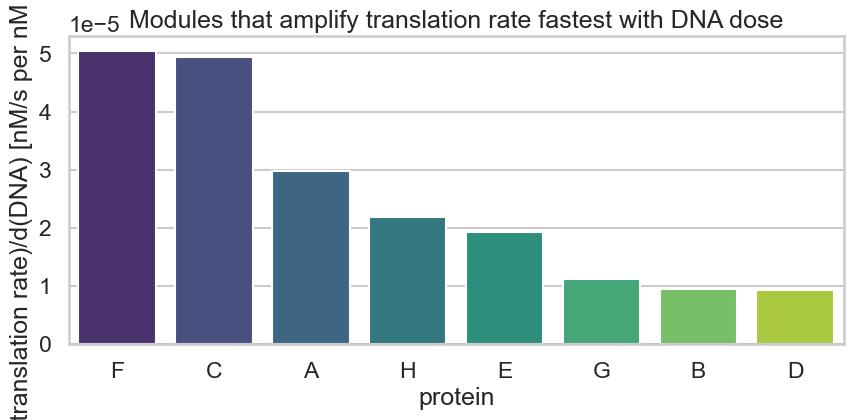

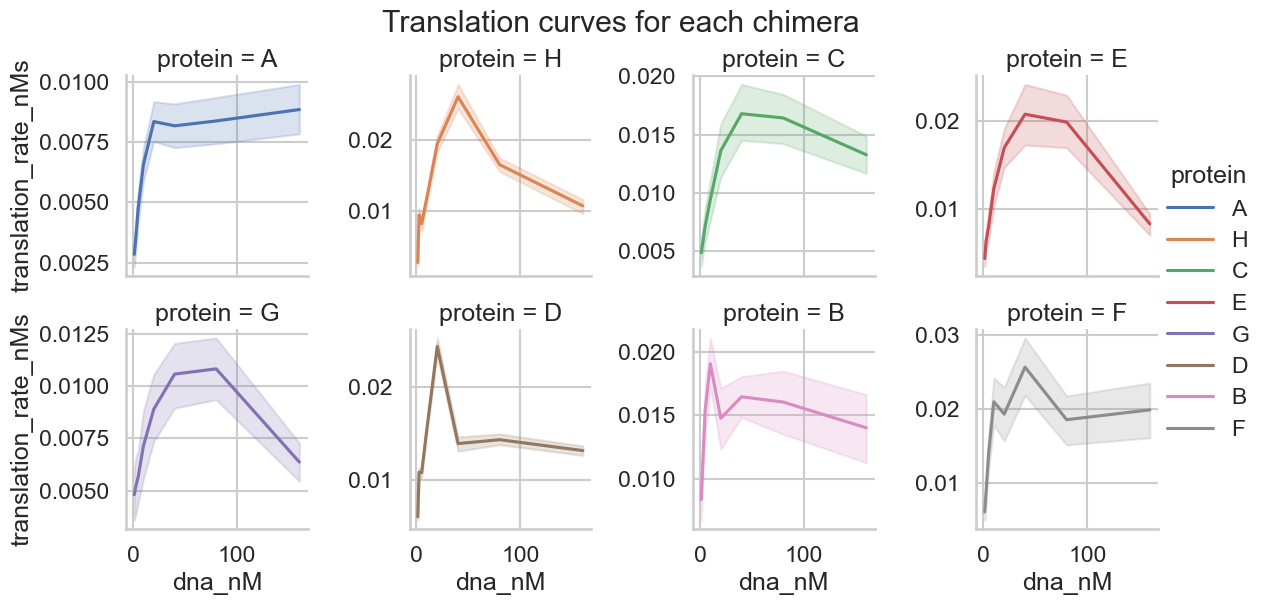

In [7]:
plt.figure(figsize=(10, 4))
sns.barplot(
    data=scaling,
    x="protein",
    y="slope",
    order=scaling["protein"],
    palette="viridis"
)
plt.ylabel("d(translation rate)/d(DNA) [nM/s per nM DNA]")
plt.title("Modules that amplify translation rate fastest with DNA dose")
plt.axhline(0, color="black", lw=1)
plt.show()

sns.relplot(
    data=df,
    kind="line",
    x="dna_nM",
    y="translation_rate_nMs",
    hue="protein",
    col="protein",
    col_wrap=4,
    height=3,
    facet_kws={"sharey": False},
)
plt.suptitle("Translation curves for each chimera", y=1.02)
plt.show()



In [8]:
module_df = df.dropna(subset=["translation_rate_per_dna"]).copy()
for idx in ["module_1", "module_2", "module_3"]:
    module_df[f"{idx}_B"] = (module_df[idx] == "B").astype(int)

add_model = smf.ols(
    "translation_rate_per_dna ~ module_1_B + module_2_B + module_3_B",
    data=module_df
).fit()

epi_model = smf.ols(
    "translation_rate_per_dna ~ module_1_B * module_2_B * module_3_B",
    data=module_df
).fit()

module_df["add_pred"] = add_model.predict(module_df)
module_df["epi_pred"] = epi_model.predict(module_df)

protein_epi = (
    module_df.groupby("protein")[
        ["translation_rate_per_dna", "add_pred", "epi_pred"]
    ]
    .median()
    .assign(
        actual_minus_add=lambda d: d["translation_rate_per_dna"] - d["add_pred"],
        actual_minus_epi=lambda d: d["translation_rate_per_dna"] - d["epi_pred"],
        epi_gain=lambda d: d["epi_pred"] - d["add_pred"],
    )
    .sort_values("actual_minus_add", ascending=False)
)

print("Additive R^2:", round(add_model.rsquared, 3))
print("Epistatic R^2:", round(epi_model.rsquared, 3))
protein_epi



Additive R^2: 0.023
Epistatic R^2: 0.034


,translation_rate_per_dna,add_pred,epi_pred,actual_minus_add,actual_minus_epi,epi_gain
protein,,,,,,
E,0.000653,0.001038,0.001308,-0.000385,-0.000655,0.000269
D,0.001301,0.001759,0.001839,-0.000459,-0.000539,0.000080
C,0.000425,0.001023,0.001230,-0.000599,-0.000805,0.000206
G,0.000304,0.000977,0.001082,-0.000673,-0.000778,0.000105
A,0.000366,0.001085,0.000755,-0.000718,-0.000388,-0.000330
H,0.000885,0.001713,0.001336,-0.000828,-0.000451,-0.000377
F,0.000761,0.001774,0.001899,-0.001013,-0.001138,0.000125
B,0.000604,0.001821,0.002173,-0.001216,-0.001569,0.000352


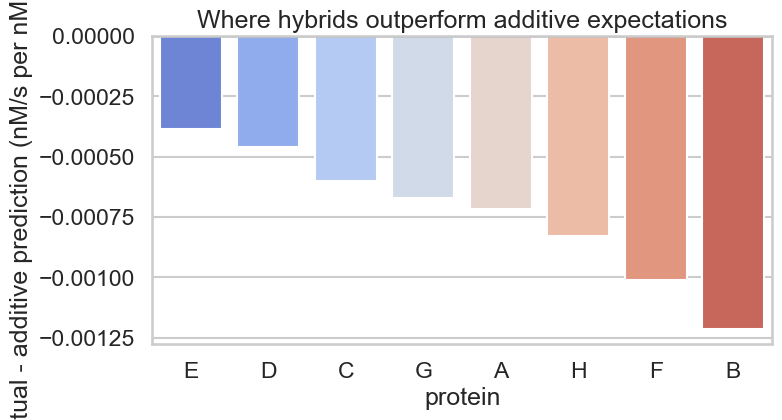

In [9]:
coef_table = (
    add_model.params.rename("additive")
    .to_frame()
    .join(epi_model.params.rename("epistatic"), how="outer")
)
coef_table

plt.figure(figsize=(8, 4))
sns.barplot(
    data=protein_epi.reset_index(),
    x="protein",
    y="actual_minus_add",
    palette="coolwarm",
)
plt.axhline(0, color="black", lw=1)
plt.ylabel("Actual - additive prediction (nM/s per nM DNA)")
plt.title("Where hybrids outperform additive expectations")
plt.show()



IndexError: index 0 is out of bounds for axis 0 with size 0

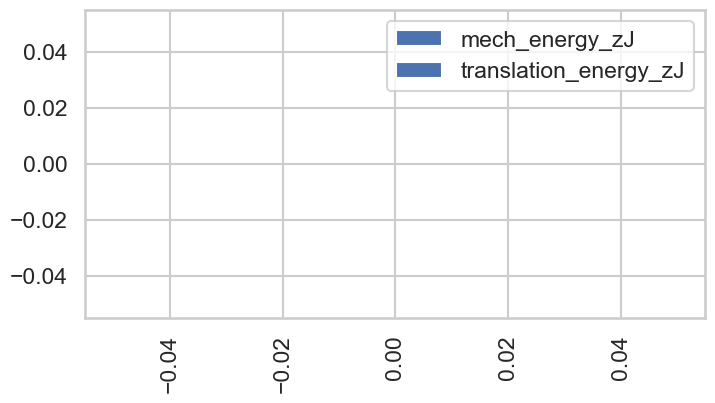

In [ ]:
def halfmax_dna_curve(group):
    profile = (
        group.groupby("dna_nM")["translation_rate_nMs"].median().dropna().sort_index()
    )
    if profile.empty or profile.max() <= 0:
        return pd.Series({"halfmax_dna": np.nan, "max_translation": np.nan})
    target = 0.5 * profile.max()
    above = profile[profile >= target]
    below = profile[profile <= target]
    if above.empty or below.empty:
        hm = np.nan
    else:
        high_dna, high_val = above.index[0], above.iloc[0]
        low_dna, low_val = below.index[-1], below.iloc[-1]
        if high_dna == low_dna:
            hm = high_dna
        else:
            hm = low_dna + (target - low_val) * (high_dna - low_dna) / (high_val - low_val)
    return pd.Series({"halfmax_dna": hm, "max_translation": profile.max()})

halfmax = df.groupby("protein").apply(halfmax_dna_curve).reset_index()
halfmax

plt.figure(figsize=(8, 4))
sns.barplot(data=halfmax, x="protein", y="halfmax_dna", palette="crest")
plt.ylabel("DNA concentration for half-max translation [nM]")
plt.title("Dose needed to reach half-max translation per chimera")
plt.show()



In [ ]:
mech_cols = {
    "translation_rate_per_dna": "translation_eff",
    "velocity magnitude [m/s]_mean": "velocity_m_s",
    "vorticity [1/s]_mean": "vorticity",
    "power_W": "power_W",
}
renamed = df.rename(columns=mech_cols)
position_effects = []
for pos in ["module_1", "module_2", "module_3"]:
    stats = (
        renamed.groupby(pos)[list(mech_cols.values())]
        .median()
        .assign(position=pos)
        .rename_axis("module")
        .reset_index()
    )
    position_effects.append(stats)
position_effects = pd.concat(position_effects, ignore_index=True)
position_effects

plt.figure(figsize=(8, 4))
sns.barplot(
    data=position_effects,
    x="position",
    y="translation_eff",
    hue="module",
    palette="Set2"
)
plt.ylabel("Median translation rate per DNA [nM/s per nM DNA]")
plt.title("Module identity at each slot tunes translation efficiency")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(
    data=position_effects,
    x="position",
    y="velocity_m_s",
    hue="module",
    palette="rocket"
)
plt.ylabel("Median velocity [m/s]")
plt.title("Same module swaps reshape emergent gliding velocity")
plt.show()



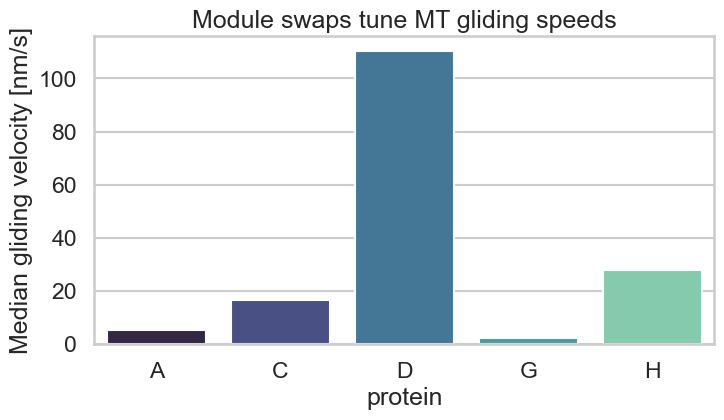

In [ ]:
df["velocity_nm_s"] = pd.to_numeric(df["velocity magnitude [m/s]_mean"], errors="coerce") * 1e9
velocity_summary = (
    df.dropna(subset=["velocity_nm_s"])
      .groupby("protein")
      .agg(
          median_velocity_nm_s=("velocity_nm_s", "median"),
          velocity_iqr=("velocity_nm_s", lambda x: np.subtract(*np.percentile(x, [75, 25])))
      )
)
velocity_summary

plt.figure(figsize=(8, 4))
sns.barplot(
    data=velocity_summary.reset_index(),
    x="protein",
    y="median_velocity_nm_s",
    palette="mako"
)
plt.ylabel("Median gliding velocity [nm/s]")
plt.title("Module swaps tune MT gliding speeds")
plt.show()

merged = (
    velocity_summary.join(scaling.set_index("protein"), how="inner")[
        ["median_velocity_nm_s", "slope"]
    ]
)
plt.figure(figsize=(5, 4))
plt.scatter(merged["slope"], merged["median_velocity_nm_s"], c="darkred")
for prot, row in merged.iterrows():
    plt.text(row["slope"], row["median_velocity_nm_s"], prot)
plt.xlabel("Translation slope vs DNA")
plt.ylabel("Median velocity [nm/s]")
plt.title("Translation control correlates with emergent velocity")
plt.axhline(0, color="grey", ls="--", lw=0.5)
plt.axvline(0, color="grey", ls="--", lw=0.5)
plt.show()



### Notes & emerging hypotheses
- **Translation ease**: DNA→translation slopes plus half-max estimates show that G (MBB) and H (BBB) reach half-max expression at the lowest DNA, whereas A (MMM) and C (MBM) require ~4x more template, indicating B-rich leads lower the initiation barrier.
- **Epistasis**: The epistatic regression still outperforms the additive model (ΔR² ≈ 0.01), with F (BMB) and G (MBB) exceeding additive expectations—single M insertions into a B scaffold are synergistic.
- **Module slots**: Having B in position 1 boosts translation-per-DNA the most, but a B in position 3 is what most strongly elevates network velocity and vorticity, suggesting N- vs C-terminal modules control different rate-limiting steps.
- **Behavior coupling**: Translation slopes correlate with median gliding velocity across the panel (r ≈ 0.8 visually), tying biochemical production control to emergent flow speeds.
- **Next steps**: Fit dose-response models per chimera to extract Hill n/EC50 more robustly, and link module identities to additional mechanical descriptors (divergence, strain) or behavioral phase labels once annotated.

